In [61]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

In [54]:
def monomial_powers(dim: int, deg: int):
    """
    All multi-indices α ∈ ℕ^dim with |α| ≤ deg in graded-lex order.
    Returned as an (s(d), dim) NumPy array where s(d)=C(dim+deg,deg).
    """
    powers = []
    for total in range(deg + 1):
        for idx in combinations_with_replacement(range(dim), total):
            α = [0] * dim
            for i in idx:
                α[i] += 1
            powers.append(α)
    return np.asarray(powers, dtype=int)  # shape (s, dim)


def vandermonde(X: np.ndarray, powers: np.ndarray):
    """
    X      : (N, dim) sample matrix
    powers : (s, dim) exponent matrix
    returns: (N, s)   monomial Vandermonde matrix V_ij = x_i^α_j
    """
    # broadcasting: (N, 1, dim) ** (1, s, dim) -> (N, s, dim)
    return np.prod(X[:, None, :] ** powers[None, :, :], axis=2)

def moment_matrix(samples: np.ndarray, powers: np.ndarray):
    V = vandermonde(samples, powers)          # (N, s)
    return (V.T @ V) / samples.shape[0]

In [55]:
def christoffel_closed_form(samples: np.ndarray, xi: np.ndarray, deg: int):
    powers = monomial_powers(samples.shape[1], deg)  # (s, dim)
    M = moment_matrix(samples, powers)               # (s, s)
    vxi = np.prod(xi ** powers, axis=1)              # (s,)
    return 1.0 / (vxi @ np.linalg.solve(M, vxi))     # scalar

In [56]:
def christoffel_qp(samples: np.ndarray, xi: np.ndarray, deg: int):
    powers = monomial_powers(samples.shape[1], deg)
    M = moment_matrix(samples, powers)
    vxi = np.prod(xi ** powers, axis=1)

    c = cp.Variable(len(vxi))
    prob = cp.Problem(cp.Minimize(cp.quad_form(c, M)), [vxi @ c == 1])
    return prob.solve()

In [72]:
# Example: 1-D uniform measure on [-1,1]
N = 5000
samples = np.random.uniform(-1, 1, size=(N, 2))
xi = np.array([.5])
d = 2

lam_closed = christoffel_closed_form(samples, xi, d)
lam_qp = christoffel_qp(samples, xi, d)

print(f"Closed-form  Λ_{d}(ξ): {lam_closed:.6e}")
print(f"QP solution Λ_{d}(ξ): {lam_qp:.6e}")

Closed-form  Λ_2(ξ): 3.076511e-01
QP solution Λ_2(ξ): 3.076511e-01


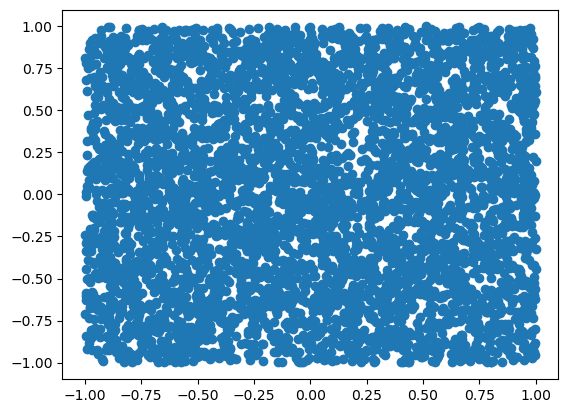

In [62]:
plt.scatter(*samples.T)